# Metric Analysis

Compile BiaPy `test_results_metrics.csv` across configs (`biapy-py_v*`) and jobs (`r0`, `data-channel`) under `metrics/biapy/`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

root = Path.cwd()
if root.name == "ipynb":
    root = root.parent

BIAPY_METRIC_ROOT = root / "metrics" / "biapy"
BIAPY_METRIC_ROOT

PosixPath('/scratch/wmz2007/neuroinfo_fruitfly/metrics/biapy')

## Load & tag all runs

In [ ]:
def _job_from_run_dir(config: str, run_dir: str) -> str:
    prefix = f"{config}_"
    return run_dir[len(prefix):] if run_dir.startswith(prefix) else run_dir


def load_biapy_metrics(metric_root: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Load every test_results_metrics.csv under metric_root.

    Returns (metrics, inventory) where metrics has config/job/run_dir/stem
    columns prepended, and inventory lists one row per discovered CSV.
    """
    paths = sorted(metric_root.glob("*/results/*/test_results_metrics.csv"))
    frames = []
    inventory_rows = []

    for path in paths:
        # metrics/biapy/{config}/results/{run_dir}/test_results_metrics.csv
        config = path.parts[-4]
        run_dir = path.parts[-2]
        job = _job_from_run_dir(config, run_dir)

        df = pd.read_csv(path)
        df = df.copy()
        df.insert(0, "config", config)
        df.insert(1, "job", job)
        df.insert(2, "run_dir", run_dir)
        stem = (
            df["file"]
            .astype(str)
            .str.replace(r"\.tiff?$", "", regex=True)
        )
        df.insert(3, "stem", stem)
        frames.append(df)

        inventory_rows.append(
            {
                "config": config,
                "job": job,
                "run_dir": run_dir,
                "n_samples": len(df),
                "path": str(path.relative_to(root)),
            }
        )

    if not frames:
        raise FileNotFoundError(
            f"No test_results_metrics.csv under {metric_root}"
        )

    metrics = pd.concat(frames, ignore_index=True)
    inventory = pd.DataFrame(inventory_rows)
    return metrics, inventory


metrics, inventory = load_biapy_metrics(BIAPY_METRIC_ROOT)
print(f"{len(metrics)} rows from {len(inventory)} runs")
metrics.head()

biapy-py_v1
biapy-py_v1
biapy-py_v2
biapy-py_v2
biapy-py_v3
biapy-py_v3
biapy-py_v4
biapy-py_v4
56 rows from 8 runs


,config,job,run_dir,stem,file,iou (f channel),iou (c channel),l1 (db channel),l1 (dn channel),0.3 TH fp,...,0.75 TH (post)fn,0.75 TH (post)precision,0.75 TH (post)recall,0.75 TH (post)accuracy,0.75 TH (post)f1,0.75 TH (post)n_true,0.75 TH (post)n_pred,0.75 TH (post)mean_true_score,0.75 TH (post)mean_matched_score,0.75 TH (post)panoptic_quality
0,biapy-py_v1,data-channel,biapy-py_v1_data-channel,JRC_SS04989-20160318_24_A2,JRC_SS04989-20160318_24_A2.tif,0.007693,0.259080,0.307023,0.236145,0,...,3,0,0,0,0,3,0,0.0,0.0,0.0
1,biapy-py_v1,data-channel,biapy-py_v1_data-channel,R14A02-20180905_65_A6,R14A02-20180905_65_A6.tif,0.004148,0.158991,0.272196,0.241990,3,...,7,0,0,0,0,7,3,0.0,0.0,0.0
2,biapy-py_v1,data-channel,biapy-py_v1_data-channel,R54A09-20181019_64_H1,R54A09-20181019_64_H1.tif,0.018312,0.392324,0.279401,0.260558,0,...,1,0,0,0,0,1,1,0.0,0.0,0.0
3,biapy-py_v1,data-channel,biapy-py_v1_data-channel,VT011145-20171222_63_I1,VT011145-20171222_63_I1.tif,0.001189,0.173653,0.285703,0.234063,0,...,9,0,0,0,0,9,0,0.0,0.0,0.0
4,biapy-py_v1,data-channel,biapy-py_v1_data-channel,VT027175-20171031_62_H3,VT027175-20171031_62_H3.tif,0.005156,0.206584,0.242241,0.241095,0,...,3,0,0,0,0,3,0,0.0,0.0,0.0


## Inventory

In [9]:
inventory

,config,job,run_dir,n_samples,path
0,biapy-py_v1,data-channel,biapy-py_v1_data-channel,7,metrics/biapy/biapy-py_v1/results/biapy-py_v1_...
1,biapy-py_v1,r0,biapy-py_v1_r0,7,metrics/biapy/biapy-py_v1/results/biapy-py_v1_...
2,biapy-py_v2,data-channel,biapy-py_v2_data-channel,7,metrics/biapy/biapy-py_v2/results/biapy-py_v2_...
3,biapy-py_v2,r0,biapy-py_v2_r0,7,metrics/biapy/biapy-py_v2/results/biapy-py_v2_...
4,biapy-py_v3,data-channel,biapy-py_v3_data-channel,7,metrics/biapy/biapy-py_v3/results/biapy-py_v3_...
5,biapy-py_v3,r0,biapy-py_v3_r0,7,metrics/biapy/biapy-py_v3/results/biapy-py_v3_...
6,biapy-py_v4,data-channel,biapy-py_v4_data-channel,7,metrics/biapy/biapy-py_v4/results/biapy-py_v4_...
7,biapy-py_v4,r0,biapy-py_v4_r0,7,metrics/biapy/biapy-py_v4/results/biapy-py_v4_...


## Summary by config × job

Mean over the 7 test samples. Detection @0.5 F1/PQ are currently all zeros; @0.3 and channel IoUs carry the signal.

In [10]:
CHANNEL_COLS = [
    "iou (f channel)",
    "iou (c channel)",
    "l1 (db channel)",
    "l1 (dn channel)",
]

DET_FIELDS = ["precision", "recall", "f1", "panoptic_quality"]
THRESHOLDS = ["0.3", "0.5", "0.75"]

DET_COLS = [
    f"{th} TH {field}"
    for th in THRESHOLDS
    for field in DET_FIELDS
]
POST_COLS = [
    f"{th} TH (post){field}"
    for th in THRESHOLDS
    for field in DET_FIELDS
]

SUMMARY_COLS = [c for c in CHANNEL_COLS + DET_COLS + POST_COLS if c in metrics.columns]

means = (
    metrics.groupby(["config", "job"], sort=True)[SUMMARY_COLS]
    .mean()
    .reset_index()
)
means

,config,job,iou (f channel),iou (c channel),l1 (db channel),l1 (dn channel),0.3 TH precision,0.3 TH recall,0.3 TH f1,0.3 TH panoptic_quality,...,0.3 TH (post)f1,0.3 TH (post)panoptic_quality,0.5 TH (post)precision,0.5 TH (post)recall,0.5 TH (post)f1,0.5 TH (post)panoptic_quality,0.75 TH (post)precision,0.75 TH (post)recall,0.75 TH (post)f1,0.75 TH (post)panoptic_quality
0,biapy-py_v1,data-channel,0.008765,0.248438,0.281006,0.237290,0.142857,0.142857,0.142857,0.047302,...,0.142857,0.047302,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,biapy-py_v1,r0,0.032603,0.022836,0.329869,0.209502,0.024975,0.231293,0.039474,0.014892,...,0.039474,0.014892,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,biapy-py_v2,data-channel,0.000000,0.156579,0.280187,0.304123,0.214286,0.163265,0.174603,0.058258,...,0.174603,0.058258,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,biapy-py_v2,r0,0.160599,0.195788,0.223130,0.208063,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,biapy-py_v3,data-channel,0.002352,0.000140,0.156181,0.192984,0.003441,0.044444,0.006384,0.002136,...,0.006384,0.002136,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,biapy-py_v3,r0,0.013391,0.022754,0.232717,0.309532,0.011487,0.280272,0.021651,0.008468,...,0.021651,0.008468,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,biapy-py_v4,data-channel,0.006663,0.033885,0.170671,0.176378,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,biapy-py_v4,r0,0.022469,0.033386,0.148558,0.251990,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
def pivot_metric(col: str) -> pd.DataFrame:
    return (
        metrics.groupby(["config", "job"])[col]
        .mean()
        .unstack("job")
        .round(4)
    )


HEADLINE = [
    "iou (f channel)",
    "iou (c channel)",
    "0.3 TH f1",
    "0.3 TH panoptic_quality",
    "0.3 TH precision",
    "0.3 TH recall",
    "0.5 TH f1",
    "0.3 TH (post)f1",
]

for col in HEADLINE:
    if col not in metrics.columns:
        continue
    print(f"\n=== mean {col} ===")
    display(pivot_metric(col))


=== mean iou (f channel) ===


job,data-channel,r0
config,,
biapy-py_v1,0.0088,0.0326
biapy-py_v2,0.0000,0.1606
biapy-py_v3,0.0024,0.0134
biapy-py_v4,0.0067,0.0225



=== mean iou (c channel) ===


job,data-channel,r0
config,,
biapy-py_v1,0.2484,0.0228
biapy-py_v2,0.1566,0.1958
biapy-py_v3,0.0001,0.0228
biapy-py_v4,0.0339,0.0334



=== mean 0.3 TH f1 ===


...

job,data-channel,r0
config,,
biapy-py_v1,0.1429,0.2313
biapy-py_v2,0.1633,0.0000
biapy-py_v3,0.0444,0.2803
biapy-py_v4,0.0000,0.0000



=== mean 0.5 TH f1 ===


job,data-channel,r0
config,,
biapy-py_v1,0.0,0.0
biapy-py_v2,0.0,0.0
biapy-py_v3,0.0,0.0
biapy-py_v4,0.0,0.0



=== mean 0.3 TH (post)f1 ===


job,data-channel,r0
config,,
biapy-py_v1,0.1429,0.0395
biapy-py_v2,0.1746,0.0000
biapy-py_v3,0.0064,0.0217
biapy-py_v4,0.0000,0.0000


## Per-sample comparison

Samples as rows, `config/job` as columns for a single metric.

In [12]:
COMPARE_METRIC = "0.3 TH f1"

per_sample = (
    metrics.assign(run=metrics["config"] + "/" + metrics["job"])
    .pivot_table(index="stem", columns="run", values=COMPARE_METRIC, aggfunc="first")
    .sort_index()
)
per_sample.round(4)

run,biapy-py_v1/data-channel,biapy-py_v1/r0,biapy-py_v2/data-channel,biapy-py_v2/r0,biapy-py_v3/data-channel,biapy-py_v3/r0,biapy-py_v4/data-channel,biapy-py_v4/r0
stem,,,,,,,,
JRC_SS04989-20160318_24_A2,0.0,0.0263,0.0000,0.0,0.0000,0.0111,0.0,0.0
R14A02-20180905_65_A6,0.0,0.1667,0.2222,0.0,0.0000,0.0667,0.0,0.0
R54A09-20181019_64_H1,1.0,0.0833,1.0000,0.0,0.0000,0.0435,0.0,0.0
VT011145-20171222_63_I1,0.0,0.0000,0.0000,0.0,0.0180,0.0000,0.0,0.0
VT027175-20171031_62_H3,0.0,0.0000,0.0000,0.0,0.0000,0.0000,0.0,0.0
VT027175-20171031_62_H4,0.0,0.0000,0.0000,0.0,0.0000,0.0000,0.0,0.0
VT050157-20171110_61_C1,0.0,0.0000,0.0000,0.0,0.0267,0.0303,0.0,0.0


## Plots

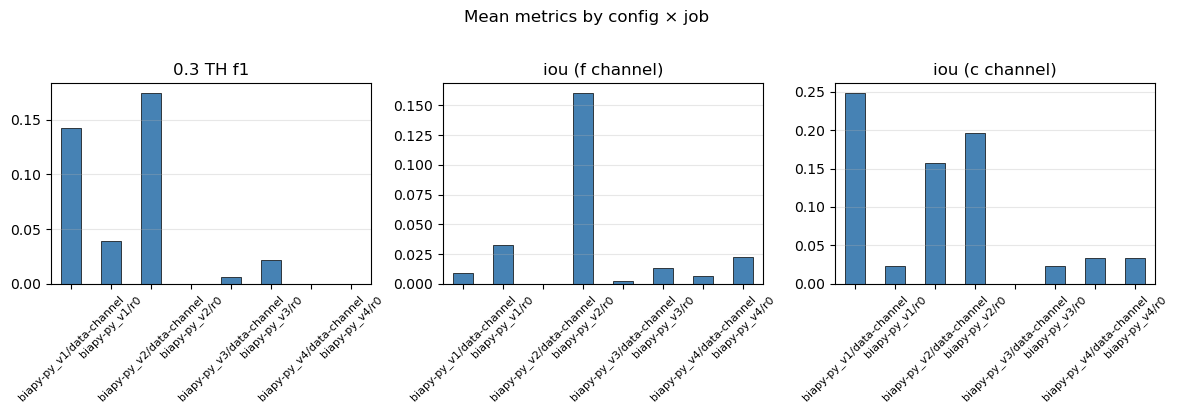

In [13]:
plot_cols = [
    "0.3 TH f1",
    "iou (f channel)",
    "iou (c channel)",
]
plot_df = means.set_index(["config", "job"])[plot_cols].copy()
plot_df.index = [f"{c}/{j}" for c, j in plot_df.index]

fig, axes = plt.subplots(1, len(plot_cols), figsize=(4 * len(plot_cols), 4), sharey=False)
for ax, col in zip(axes, plot_cols):
    plot_df[col].plot(kind="bar", ax=ax, color="steelblue", edgecolor="black", linewidth=0.5)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Mean metrics by config × job", y=1.02)
fig.tight_layout()
plt.show()

## Persist compiled CSV

In [14]:
out_path = BIAPY_METRIC_ROOT / "compiled_test_results_metrics.csv"
metrics.to_csv(out_path, index=False)
print(f"Wrote {len(metrics)} rows → {out_path.relative_to(root)}")

Wrote 56 rows → metrics/biapy/compiled_test_results_metrics.csv
